# Lab IV: Linear Models
### Answer all three sets of questions

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
- A model is linear if it models the relationship y = B0 + B1x1+B2x2+…+Bnxn, where B0 is our intercept and B1 is our slope coefficient for our first feature variable, etc.
2.  do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
- The coefficient is a 1 if the categorical variable is present and a 0 if it is not. We do this so we can model numerical relationships with categorical variables as our model cannot interpret categorical variables. We set a baseline and our dummy variables represent the relationship to the baseline, whether present or not. The average of our dummy variables represent the count of them. Our baseline dummy variable becomes the intercept of our model, B0.
3. Can linear regression be used for classification? Explain why, or why not.
- Linear regression **can not** be used for classification. Linear regression is used to model continuous target variables, not discrete ones.
4. If you have a high accuracy on training but low on testing, what might be the problem? It's also possible you'll see a pattern in the residuals
- This indicates that our model is over fitting and often occurs when we include too many parameters or too high of a degree. Our model will closely follows the training data but when it must generalize to the testing data it is not adaptable or generalizable. A pattern in the residuals may indicate that we are not using the correct degree, such as a third degree model for a second degree relationship.
5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
   1. We can use non-linear models such as decision trees or neural networks.
   2. We can add non-linear components as additional features by raising our existing existing features to higher powers, such as adding a "population_squared" feature to our model that already has a population feature.
6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
- The interpretation of our intercept is the value of our predicted target variable when all of our beta components being multiplied by our feature variables our equal to 0. The slope coefficient for our variable indicates the predicted change in our target variable associated with a one-unit increase in our variable when all other variables are held constant. The coefficient for our dummy variables indicate the change in our target variable associated with the change is presence of our dummy variable(present/not present). It is the difference between the presence of our target variable and our baseline.

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [ ]:
# Reading in data
q1_clean_df = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
q1_clean_df.head()

#### P1

In [ ]:
neighbourhood_data = q1_clean_df.groupby('Neighbourhood ')
average_prices = neighbourhood_data['Price'].mean()
average_scores = neighbourhood_data['Review Scores Rating'].mean()
average_prices

-Manhattan is the neighborhood with the highest prices at an average of 183.66 per night

In [ ]:
sns.kdeplot(data=q1_clean_df, x='Price', hue='Neighbourhood ')

In [ ]:
q1_clean_df['log_price'] = np.log(q1_clean_df['Price'])
sns.kdeplot(data=q1_clean_df, x='log_price', hue='Neighbourhood ')

#### P2

In [ ]:
#Seperate into feature, target 
X = q1_clean_df.iloc[:, 1:5]
Y = q1_clean_df['Price']

X_neigh = q1_clean_df[['Neighbourhood ']].astype('category')

# One hot encoding without intercept
X_neigh_1h = pd.get_dummies(X_neigh, columns=['Neighbourhood '])

mod1 = LinearRegression(fit_intercept=False).fit(X_neigh_1h, Y)
results = pd.DataFrame({'variable':mod1.feature_names_in_, 'coefficient': mod1.coef_}) 
results

The linear regression models matches the average price by neighborhood. When we one hot encode and do not include an intercept, the model interprets each variable as a standalone variable, each neighborhood as its own category without reference to the baseline. Because of this the coefficient outputs exactly match up with the means. The coefficients in a regression of a continuous variable on one categorical variable is their mean value.

#### P3

In [ ]:
X_neigh_1h_2 = pd.get_dummies(X_neigh, columns=['Neighbourhood '],  drop_first=True)
mod2 = LinearRegression(fit_intercept=True).fit(X_neigh_1h_2, Y)
print("Bronx:", mod2.intercept_)
results_2 = pd.DataFrame({'variable':mod2.feature_names_in_, 'coefficient': mod2.coef_}) 
results_2

The coefficients are now being interpreted in the context of the other ones. By dropping the Bronx from the equation we now interpret the other coefficients in terms of the Bronx, which is the intercept(when all other neighborhoods are false). We can find the other coefficients by adding them to our intercept.

#### P4

In [ ]:
# Selecting only the features we want to look at
X1 = X[['Review Scores Rating', 'Neighbourhood ']]
#Get dummies for neighborhood
X_neigh_1h = pd.get_dummies(X1, columns=['Neighbourhood '], drop_first = True)
#Test train split
x_train, x_test, y_train, y_test = train_test_split(X_neigh_1h, Y, train_size=0.8, random_state=99)

#Running regression
mod3 = LinearRegression()
mod3.fit(x_train, y_train)
# Pulling key variables
y_pred = mod3.predict(x_test)
test_set = X_neigh_1h.loc[x_test.index].copy()
test_set["Predicted Price"] = y_pred.round(1)
test_set["Error"] = (y_pred - y_test)
# Calculating metrics
rmse = np.sqrt(((y_pred - y_test) ** 2).mean())
print("RMSE:", rmse.round(1))
r2 = r2_score(y_test, y_pred)
print("R^2:", round(r2, 3))

pd.DataFrame({'variable':mod3.feature_names_in_, 'coefficient': mod3.coef_}) 


Our RMSE value is 121.5 and our R^2 value is 0.072. The coefficient on review scores rating 1.007598, meaning that price increases by 1.007598 for each one unit increase in review scores rating. The most expensive property you can rent is one in Manhattan.

#### P5

In [40]:
# Selecting only the features we want to look at
X2 = X[['Review Scores Rating', 'Neighbourhood ', 'Property Type']]
#Get dummies for neighborhood
X2_1h = pd.get_dummies(X2, columns=['Neighbourhood ', 'Property Type'], drop_first = True)
#Test train split
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(X2_1h, Y, train_size=0.8, random_state=99)

#Running regression
mod4 = LinearRegression()
mod4.fit(x_train_1, y_train_1)
# Pulling key variables
y_pred_1 = mod4.predict(x_test_1)
test_set_1 = X2_1h.loc[x_test_1.index].copy()
test_set_1["Predicted Price"] = y_pred_1.round(1)
test_set_1["Error"] = (y_pred_1 - y_test_1)
# Calculating metrics
rmse_1 = np.sqrt(((y_pred_1 - y_test_1) ** 2).mean())
print("RMSE:", rmse_1.round(1))
r2_1 = r2_score(y_test_1, y_pred_1)
print("R^2:", round(r2_1, 3))

coef_df_1 = pd.DataFrame({'Variable': mod4.feature_names_in_, 'Coefficient': mod4.coef_})

coef_df_1[0::]


RMSE: 120.6
R^2: 0.086


,Variable,Coefficient
0,Review Scores Rating,1.006896e+00
1,Neighbourhood _Brooklyn,6.461103e+01
2,Neighbourhood _Manhattan,1.255588e+02
3,Neighbourhood _Queens,3.166652e+01
4,Neighbourhood _Staten Island,7.462722e+01
5,Property Type_Bed & Breakfast,-3.274745e+01
6,Property Type_Boat,6.195455e+01
7,Property Type_Bungalow,5.628966e+01
8,Property Type_Cabin,1.421085e-14
9,Property Type_Camper/RV,-2.254063e+01


The R^2 value is 0.086. The RMSE is 120.6. The most expensive property type is one that is in Manhattan because it has the highest coefficient.

#### P6

The coefficient changing means that the influence that score has on price changes when property type is considered vs. when it is not. In regression, we are aiming to fit a model to all of our data. When we consider additional factors our coefficients change as they must adapt to all features of our model. The review scores rating decreases because it has less of a positive impact on our model when we expand to consider property type.

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

#### P1

In [ ]:
# Loading in data
cars_data = pd.read_csv("../data/cars_hw.csv")
cars_data.head()

# Boxplot to see if we have outliers for price
sns.boxplot(x = cars_data['Price'])

In [ ]:
sns.boxplot(x = cars_data['Mileage_Run'])

It seems like we have a lot of high outliers for price. We will remove rows where price is greater than $175,000.

In [ ]:
cars_data = cars_data[cars_data['Price']<=1750000]
cars_data.reset_index(drop = True, inplace = True)
cars_data.head()

In [ ]:
sns.histplot(x = cars_data["Price"])

The histogram shows that the 'price' attribute is still skewed to the right. We will perform a log transformation as our data is strictly positive and heavily skewed towards larger values

In [ ]:
cars_data['Log_Price'] = np.log(cars_data['Price'])
sns.histplot(x = cars_data["Log_Price"])

#### P2

In [ ]:
cars_data['Price'].describe()

In [ ]:
cars_data['Log_Price'].describe()

In [ ]:
# Kernel density plot with price(not log):
sns.kdeplot(data=cars_data, x='Price')

In [ ]:
# Kernel density plot with price(log):
sns.kdeplot(data=cars_data, x='Log_Price')

It is clear that the distribution of log price looks more normalized than just price

In [ ]:
(cars_data['Price'].groupby(cars_data['Make'])).describe()

In [ ]:
sns.kdeplot(data=cars_data, x='Price', hue='Make')

The most expensive car brands by mean are MG Motors(low density, frequency), Kia, Mahindra, and Jeep. Generally speaking, there are a couple of cars that have very high densities and average price and a few cars that have low densities and either very low or high densities. Keep in mind, we removed the high outliers for price so we may have removed the most expensive car brands.

#### P3

In [ ]:
# For our regression model we want to include log price, not price, because of its distribution
cars_X = cars_data.iloc[:, :-2]
cars_Y = cars_data['Log_Price']

x_train_cars, x_test_cars, y_train_cars, y_test_cars = train_test_split(cars_X, cars_Y, train_size=0.8, random_state=99)
print(x_train_cars.shape[0], y_train_cars.shape[0], x_test_cars.shape[0], y_test_cars.shape[0])

#### P4

Numeric variables only:

In [41]:
# Selecting only numeric cols
numeric_cols = ['Mileage_Run', 'Make_Year']
x_train_numeric = x_train_cars[numeric_cols]
x_test_numeric = x_test_cars[numeric_cols]

#Running regression
mod5 = LinearRegression()
mod5.fit(x_train_numeric, y_train_cars)
# Pulling key variables
y_pred_numeric = mod5.predict(x_test_numeric)
test_set_numeric = x_test_numeric.copy()
test_set_numeric["Predicted Price"] = y_pred_numeric.round(1)
test_set_numeric["Error"] = (y_pred_numeric - y_test_cars).astype(float)
# Calculating metrics
rmse_num = np.sqrt(((y_pred_numeric - y_test_cars) ** 2).mean())
print("RMSE:", rmse_num.round(3))
r2_num = r2_score(y_test_cars, y_pred_numeric)
print("R^2:", round(r2_num, 3))
# Predictions on the training set
y_pred_numeric_train = mod5.predict(x_train_numeric)
rmse_train_numeric = np.sqrt(((y_pred_numeric_train - y_train_cars) ** 2).mean())
r2_train_numeric = r2_score(y_train_cars, y_pred_numeric_train)
print("Training RMSE:", rmse_train_numeric.round(3))
print("Training R^2:", round(r2_train_numeric, 3))


RMSE: 0.344
R^2: 0.349
Training RMSE: 0.316
Training R^2: 0.389


Dummy variables

In [ ]:
# Making list of categorical variables
categorical_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission', 'Transmission_Type']
# Combine to change to categorical variables
combined_cat = pd.concat([x_train_cars[categorical_cols], x_test_cars[categorical_cols]], axis=0)

# Convert variables to categorical types
combined_cat = combined_cat.astype('category')

# Get dummies, one hot encoding
combined_cat_1h = pd.get_dummies(combined_cat, drop_first=True)

# Back to training and testing splits
x_train_cat_1h = combined_cat_1h.iloc[:len(x_train_cars)]  # First part is training
x_test_cat_1h = combined_cat_1h.iloc[len(x_train_cars):] 

# Performing regression
mod6 = LinearRegression()
mod6.fit(x_train_cat_1h, y_train_cars)
y_pred_cat = mod6.predict(x_test_cat_1h)

# Calculating metrics
rmse_cat = np.sqrt(((y_pred_cat - y_test_cars) ** 2).mean())
print("RMSE:", rmse_cat.round(3))
r2_cat = r2_score(y_test_cars, y_pred_cat)
print("R^2:", round(r2_cat, 3))

The categorical variable model performs better on the test set(higher R^2, lower RMSE)

Combining both: 

In [ ]:
# Combining both methods 
x_train_combined = pd.concat([x_train_numeric, x_train_cat_1h], axis=1)
x_test_combined = pd.concat([x_test_numeric, x_test_cat_1h], axis=1)

# Performing Regression:
mod_combined = LinearRegression()
mod_combined.fit(x_train_combined, y_train_cars)
y_pred_combined = mod_combined.predict(x_test_combined)

# Calculating and outputting metrics
rmse_combined = np.sqrt(mean_squared_error(y_test_cars, y_pred_combined))
r2_combined = r2_score(y_test_cars, y_pred_combined)
print("RMSE:", rmse_combined.round(3))
print("R^2:", round(r2_combined, 3))

The combined model performs much better than the first two models. By considering both our categorical and numeric variables we see an increase in over 0.2 of our categorical model and over 0.4 for our numeric model for R^2. RMSE also decreases.

#### P5

In [42]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initiate empty list to store results
results = []

# Loop through different polynomial degrees
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    x_train_poly = poly.fit_transform(x_train_numeric)
    x_test_poly = poly.transform(x_test_numeric) 

    # Same procedure as before
    mod_poly = LinearRegression()
    mod_poly.fit(x_train_poly, y_train_cars)
    y_pred_poly = mod_poly.predict(x_test_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_test_cars, y_pred_poly))
    r2_poly = r2_score(y_test_cars, y_pred_poly)

    # Store results
    results.append({"Degree": d, "RMSE": round(rmse_poly, 3), "R^2": round(r2_poly, 3)})

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
results_df


,Degree,RMSE,R^2
0,1,0.344,0.349
1,2,0.341,0.361
2,3,0.343,0.352
3,4,0.343,0.351
4,5,0.343,0.352
5,6,0.342,0.357
6,7,0.361,0.283
7,8,0.392,0.155
8,9,0.398,0.127
9,10,0.403,0.106


The R^2 value for our best model is 0.361, 0.12 better than our original model of our degree 1. The RMSE for our second degree model is 0.341, better than our original model by 0.03. The R^2 value starts to decrease after we get past second degree, but it doesn't start significantly decreasing until after we get to degree 7.

In [ ]:
poly_2 = PolynomialFeatures(degree=2)
x_train_2 = poly_2.fit_transform(x_train_numeric)
x_test_2 = poly_2.transform(x_test_numeric) 
mod_poly_2 = LinearRegression()
mod_poly_2.fit(x_train_2, y_train_cars)
y_pred_2 = mod_poly_2.predict(x_test_2)

sns.scatterplot(x = y_pred_2, y = y_test_cars)
plt.plot([y_test_cars.min(), y_test_cars.max()], [y_test_cars.min(), y_test_cars.max()], 'r--')

Although there isn't the strongest relationship, the data generally falls along the diagonal. Since we have seen low R^2 values overall it makes sense that the relationship doesn't perfectly follow the diagonal.

In [ ]:
residuals_2 = y_test_cars - y_pred_2
plt.figure(figsize=(8, 6))
sns.kdeplot(residuals_2)
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Residuals")
plt.show()

The results **do** look roughly bell shaped around 0. The model does a good job minimizing error and but the correlation between the numeric variables and our output is not very strong. We must consider both our categorical and numeric variables to perform a strong regression on car prices in this case as they both have a significant impact.

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

In [43]:
nba_data = pd.read_csv("../data/nba2k-full.csv")
nba_data.head()

,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version
0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,6-9 / 2.06,250 lbs. / 113.4 kg.,$37436858,USA,2003,1,1,NaN,NBA2k20
1,Kawhi Leonard,97,#2,Los Angeles Clippers,F,06/29/91,6-7 / 2.01,225 lbs. / 102.1 kg.,$32742000,USA,2011,1,15,San Diego State,NBA2k20
2,Giannis Antetokounmpo,96,#34,Milwaukee Bucks,F-G,12/06/94,6-11 / 2.11,242 lbs. / 109.8 kg.,$25842697,Greece,2013,1,15,NaN,NBA2k20
3,Kevin Durant,96,#7,Brooklyn Nets,F,09/29/88,6-10 / 2.08,230 lbs. / 104.3 kg.,$37199000,USA,2007,1,2,Texas,NBA2k20
4,James Harden,96,#13,Houston Rockets,G,08/26/89,6-5 / 1.96,220 lbs. / 99.8 kg.,$38199000,USA,2009,1,3,Arizona State,NBA2k20


The dataset I selected contains information of NBA players in the video game NBA 2k20. I want to see if there is correlation between the player's information and their overall rating(0-99). Mainly I want to explore the relationship between salary and rating so we will look at those variables.

<Axes: >

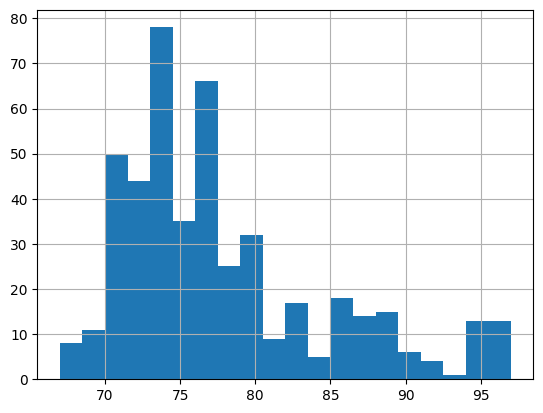

In [47]:
nba_data['rating'].hist(bins=20)

{'whiskers': [<matplotlib.lines.Line2D at 0xffff37486fc0>,
 'caps': [<matplotlib.lines.Line2D at 0xffff37334d10>,
 'boxes': [<matplotlib.lines.Line2D at 0xffff3743b650>],
 'medians': [<matplotlib.lines.Line2D at 0xffff37335790>],
 'fliers': [<matplotlib.lines.Line2D at 0xffff373340b0>],
 'means': []}

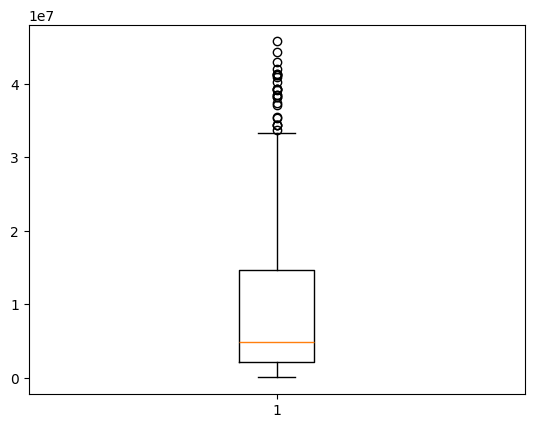

In [57]:
plt.boxplot(nba_data['salary'])

{'whiskers': [<matplotlib.lines.Line2D at 0xffff37354590>,
 'caps': [<matplotlib.lines.Line2D at 0xffff37354b60>,
 'boxes': [<matplotlib.lines.Line2D at 0xffff37354320>],
 'medians': [<matplotlib.lines.Line2D at 0xffff37355100>],
 'fliers': [<matplotlib.lines.Line2D at 0xffff373553a0>],
 'means': []}

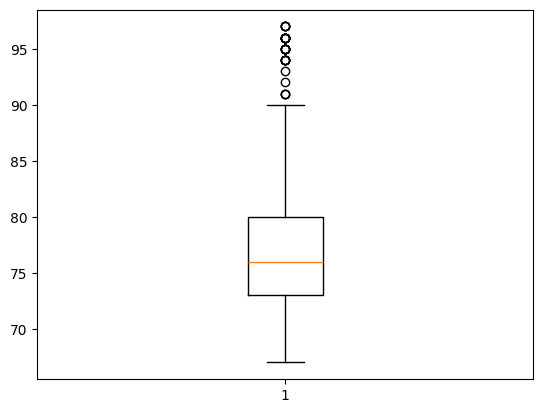

In [58]:
plt.boxplot(nba_data['rating'])

Our NBA salary and rating data seems to have some high outliers. This makes sense as some players make incredibly high amounts of money compared to the average, and only a few players are rated above 90 while most ratings are between 70 and 80. We will perform a log transformation on our salary and rating variables and add it to our data set.

In [59]:
nba_data['log_salary'] = np.log(nba_data['salary'])
nba_data['log_rating'] = np.log(nba_data['rating'])
nba_data.head()

,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version,log_salary,log_rating
0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,6-9 / 2.06,250 lbs. / 113.4 kg.,37436858.0,USA,2003,1,1,NaN,NBA2k20,17.438166,4.574711
1,Kawhi Leonard,97,#2,Los Angeles Clippers,F,06/29/91,6-7 / 2.01,225 lbs. / 102.1 kg.,32742000.0,USA,2011,1,15,San Diego State,NBA2k20,17.304169,4.574711
2,Giannis Antetokounmpo,96,#34,Milwaukee Bucks,F-G,12/06/94,6-11 / 2.11,242 lbs. / 109.8 kg.,25842697.0,Greece,2013,1,15,NaN,NBA2k20,17.067539,4.564348
3,Kevin Durant,96,#7,Brooklyn Nets,F,09/29/88,6-10 / 2.08,230 lbs. / 104.3 kg.,37199000.0,USA,2007,1,2,Texas,NBA2k20,17.431792,4.564348
4,James Harden,96,#13,Houston Rockets,G,08/26/89,6-5 / 1.96,220 lbs. / 99.8 kg.,38199000.0,USA,2009,1,3,Arizona State,NBA2k20,17.458320,4.564348


The other variables we will look at are draft year, draft round, and draft pick. This will allow us to see if experience and where you are picked impacts rating. We will drop undrafted players.

In [61]:
nba_data['pick'] = nba_data['draft_peak']
nba_data = nba_data[nba_data['pick'] != 'Undrafted']


In [62]:
nba_X = nba_data[['log_salary', 'pick', 'draft_year']]
nba_Y = nba_data[['log_rating']]

#### P3

In [63]:
nba_x_train, nba_x_test, nba_y_train, nba_y_test = train_test_split(nba_X, nba_Y, train_size=0.8, random_state=45)

#### P4

We will run regressions on each of our target variables(pick, salary, year) to see which have the highest correlation and lowest error.

#### Salary

In [64]:
x_train_sal = nba_x_train['log_salary'].to_frame()
x_test_sal = nba_x_test['log_salary'].to_frame()

#Running regression
sal_mod = LinearRegression()
sal_mod.fit(x_train_sal, nba_y_train)
# Calculating predictions
y_pred_sal = sal_mod.predict(x_test_sal)
# Calculating metrics
rmse_sal = np.sqrt(((y_pred_sal - nba_y_test) ** 2).mean())
print("RMSE:", rmse_sal.round(3))
r2_sal = r2_score(nba_y_test, y_pred_sal)
print("R^2:", round(r2_sal, 3))

RMSE: log_rating    0.064
dtype: float64
R^2: 0.513


#### Pick

In [65]:
x_train_pick = nba_x_train['pick'].to_frame()
x_test_pick = nba_x_test['pick'].to_frame()

#Running regression
pick_mod = LinearRegression()
pick_mod.fit(x_train_pick, nba_y_train)
# Calculating predictions
y_pred_pick = pick_mod.predict(x_test_pick)
# Calculating metrics
rmse_pick = np.sqrt(((y_pred_pick - nba_y_test) ** 2).mean())
print("RMSE:", rmse_pick.round(3))
r2_pick = r2_score(nba_y_test, y_pred_pick)
print("R^2:", round(r2_pick, 3))

RMSE: log_rating    0.082
dtype: float64
R^2: 0.214


#### Year

In [66]:
x_train_year = nba_x_train['draft_year'].to_frame()
x_test_year = nba_x_test['draft_year'].to_frame()

#Running regression
year_mod = LinearRegression()
year_mod.fit(x_train_year, nba_y_train)
# Calculating predictions
y_pred_year = year_mod.predict(x_test_year)
# Calculating metrics
rmse_year = np.sqrt(((y_pred_year - nba_y_test) ** 2).mean())
print("RMSE:", rmse_year.round(3))
r2_year = r2_score(nba_y_test, y_pred_year)
print("R^2:", round(r2_year, 3))

RMSE: log_rating    0.084
dtype: float64
R^2: 0.161


#### All variables

In [68]:
#Running regression
all_mod = LinearRegression()
all_mod.fit(nba_x_train, nba_y_train)
# Calculating predictions
y_pred_all = all_mod.predict(nba_x_test)
# Calculating metrics
rmse_all = np.sqrt(((y_pred_all - nba_y_test) ** 2).mean())
print("RMSE:", rmse_all.round(3))
r2_all = r2_score(nba_y_test, y_pred_all)
print("R^2:", round(r2_all, 3))

RMSE: log_rating    0.062
dtype: float64
R^2: 0.547


#### P5

For the individual models salary model performed the best, with the lowest RMSE and the highest R^2 score. The R^2 scored indicates a moderate correlation between salary and rating, while the other models showed a weak correlation. This makes sense as the best players in the NBA tend to be payed the most. This won't always hold true as young players tend to make less money but may be some of the best in the league. It seems that the worst predictor of rating was draft pick. Overall, the model considering all variables performed the best. 

#### P6

Throughout the process of this question, and the lab overall, I have learned that sometimes our intuition leads us astray and we need to explore many possibilites, not just the ones we think are correct. I would have expected the relationship between draft pick and rating to be incredibly strong, but that was not the case. Testing on multiple explanatory variables and considering more variables in our model can lead to stronger correlation and lower error, at least to an extent.

:::{important}
### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it here

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:
:::

In [ ]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 
1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

:::{tip}
### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 

:::
